In [1]:
import gymnasium as gym

env = gym.make('FrozenLake-v1', is_slippery=False)

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

state, info = env.reset()
print("Starting state:", state)

Number of states: 16
Number of actions: 4
Starting state: 0


In [4]:
import numpy as np

# the q-table starts as all zeros - the agent knows nothing yet
q_table = np.zeros((env.observation_space.n, env.action_space.n))

# training settings
episodes = 2000          # how many times the agent plays the game
learning_rate = 0.8      # how much new info overrides old info
discount_factor = 0.95   # how much future rewards matter vs immediate ones
epsilon = 1.0             # starting exploration rate (100% random at first)
epsilon_decay = 0.001     # how fast exploration decreases over time
min_epsilon = 0.01

rewards_per_episode = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        # exploration vs exploitation
        if np.random.random() < epsilon:
            action = env.action_space.sample()  # random action, exploring
        else:
            action = np.argmax(q_table[state])  # best known action, exploiting

        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # the actual q-learning update rule
        old_value = q_table[state, action]
        next_max = np.max(q_table[new_state])
        new_value = old_value + learning_rate * (reward + discount_factor * next_max - old_value)
        q_table[state, action] = new_value

        state = new_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(min_epsilon, epsilon - epsilon_decay)

print("Training complete")
print("Success rate in last 100 episodes:", np.mean(rewards_per_episode[-100:]))

Training complete
Success rate in last 100 episodes: 1.0


In [5]:
# testing the trained agent with zero exploration - always picks its best known action

test_episodes = 100
successes = 0

for episode in range(test_episodes):
    state, info = env.reset()
    done = False

    while not done:
        action = np.argmax(q_table[state])  # always exploit, never explore
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    if reward == 1:
        successes += 1

print(f"Test success rate: {successes}/{test_episodes} = {successes/test_episodes}")

Test success rate: 100/100 = 1.0


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/training_progress.png'

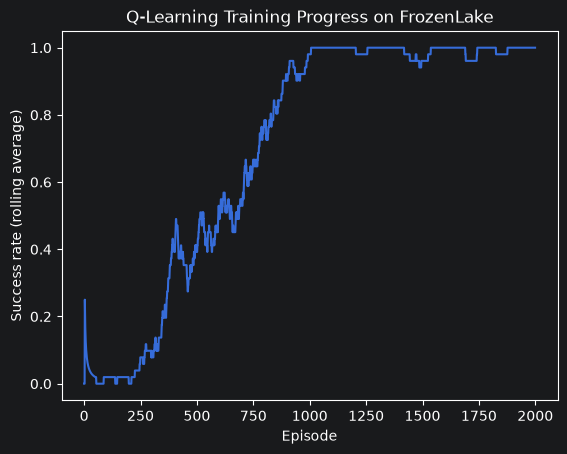

In [7]:
import matplotlib.pyplot as plt

# plotting how the agent's performance improved over training
window = 50
rolling_avg = [np.mean(rewards_per_episode[max(0,i-window):i+1]) for i in range(len(rewards_per_episode))]

plt.plot(rolling_avg)
plt.xlabel('Episode')
plt.ylabel('Success rate (rolling average)')
plt.title('Q-Learning Training Progress on FrozenLake')
plt.savefig('../outputs/training_progress.png')
plt.show()

In [8]:
import os
print(os.getcwd())

C:\Users\hp\PycharmProjects\neuro-rl-game-theory\notebooks\notebooks


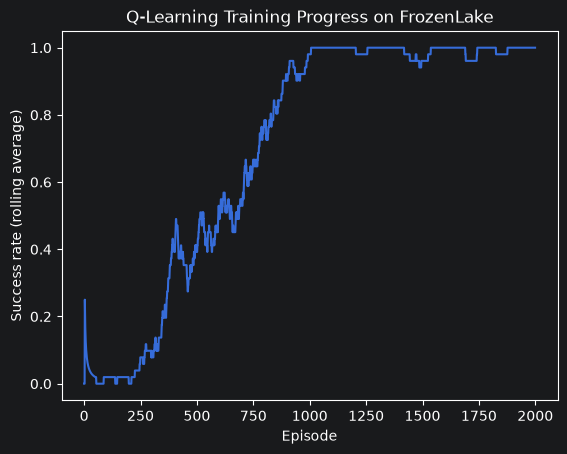

In [9]:
import matplotlib.pyplot as plt

window = 50
rolling_avg = [np.mean(rewards_per_episode[max(0,i-window):i+1]) for i in range(len(rewards_per_episode))]

plt.plot(rolling_avg)
plt.xlabel('Episode')
plt.ylabel('Success rate (rolling average)')
plt.title('Q-Learning Training Progress on FrozenLake')
plt.savefig('../../outputs/training_progress.png')
plt.show()